## Robustness Results (mCE and Relative mCE)

This notebook consolidates robustness metrics from saved CE JSONL files and generates:

- CE tables by corruption and model (15 **common** corruptions only; same set used for mCE)
- Summary tables with Clean Accuracy, mCE, and Relative mCE (mCE / Relative mCE averaged over those 15)
- Architecture Corruption Robustness plots for each dataset (saved under `figures/`)

Inputs (under `results/`):

- `cifar100c_baseline-MCUNet_Official_ce_results.jsonl`
- `cifar10c_baseline-MCUNet_ce_results.jsonl`
- `wakevision_baseline-MCUNet_ce_results.jsonl`

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "src").is_dir())))
from src.paths import ROOT


In [3]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = ROOT / "results"

DATASETS = {
    "cifar10c": {
        "label": "CIFAR-10-C",
        "jsonl": RESULTS_DIR / "cifar10c_baseline-MCUNet_ce_results.jsonl",
        "baseline": "MCUNet_Official",
        "clean_acc": RESULTS_DIR / "cifar10_clean_accuracy.json",
        # Old result files may still use MCUNet as model key.
        "aliases": {"MCUNet": "MCUNet_Official"},
        "plot_pdf": ROOT / "figures" / "cifar10c_architecture_corruption_robustness.pdf",
    },
    "cifar100c": {
        "label": "CIFAR-100-C",
        "jsonl": RESULTS_DIR / "cifar100c_baseline-MCUNet_ce_results.jsonl",
        "baseline": "MCUNet_Official",
        "clean_acc": RESULTS_DIR / "cifar100_clean_accuracy.json",
        "aliases": {},
        "plot_pdf": ROOT / "figures" / "cifar100c_architecture_corruption_robustness.pdf",
    },
    "wakevision": {
        "label": "Wake Vision-C",
        "jsonl": RESULTS_DIR / "wakevision_baseline-MCUNet_ce_results.jsonl",
        "baseline": "MCUNet",
        "clean_acc": None,
        "aliases": {},
        # From the clean-eval output in wake_vision_robustness.ipynb.
        "clean_acc_fallback": {
            "MobileNetV3Small": 0.8613,
            "EfficientNetB0": 0.8773,
            "MCUNet": 0.8127,
        },
        "plot_pdf": ROOT / "figures" / "wakevision_architecture_corruption_robustness.pdf",
    },
}

In [4]:
def _load_json(path: Path, default=None):
    if default is None:
        default = {}
    if path is None or (not Path(path).exists()):
        return default
    return json.loads(Path(path).read_text(encoding="utf-8"))


def _load_latest_jsonl(path: Path, aliases: dict[str, str] | None = None) -> list[dict]:
    if aliases is None:
        aliases = {}
    latest = {}
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        row = json.loads(line)
        model = aliases.get(row.get("model"), row.get("model"))
        corr = row.get("corruption")
        if model is None or corr is None:
            continue
        row = dict(row)
        row["model"] = model
        latest[(model, corr)] = row
    return list(latest.values())


def _err(acc: float) -> float:
    return 1.0 - float(acc)


# Hendrycks & Dietterich (CIFAR-10-C / CIFAR-100-C): 15 common corruptions for mCE.
# Holdouts (excluded from mCE): speckle_noise, gaussian_blur, spatter, saturate.
COMMON_CORRUPTIONS_15 = frozenset(
    [
        "gaussian_noise",
        "shot_noise",
        "impulse_noise",
        "defocus_blur",
        "glass_blur",
        "motion_blur",
        "zoom_blur",
        "snow",
        "frost",
        "fog",
        "brightness",
        "contrast",
        "elastic_transform",
        "pixelate",
        "jpeg_compression",
    ]
)


def _compute_mce(rows: list[dict]) -> pd.Series:
    df = pd.DataFrame(rows)
    df = df[df["corruption"].isin(COMMON_CORRUPTIONS_15)]
    return df.groupby("model")["ce_mean_1_5"].mean().sort_values() * 100.0


def _compute_relative_mce(rows: list[dict], clean_acc: dict[str, float], baseline_name: str) -> pd.Series:
    if not clean_acc or baseline_name not in clean_acc:
        return pd.Series(dtype=float)

    df = pd.DataFrame(rows)
    rel_by_model = {}

    for model, g_model in df.groupby("model"):
        if model not in clean_acc:
            continue

        model_clean_err = _err(clean_acc[model])
        baseline_clean_err = _err(clean_acc[baseline_name])

        rel_ce_vals = []
        for corr in sorted(g_model["corruption"].unique()):
            if corr not in COMMON_CORRUPTIONS_15:
                continue
            row_model = g_model[g_model["corruption"] == corr]
            row_base = df[(df["model"] == baseline_name) & (df["corruption"] == corr)]
            if row_model.empty or row_base.empty:
                continue

            rm = row_model.iloc[-1]
            rb = row_base.iloc[-1]

            num_rel = 0.0
            den_rel = 0.0
            ok = True
            for s in [1, 2, 3, 4, 5]:
                am = rm.get(f"acc_s{s}")
                ab = rb.get(f"acc_s{s}")
                if am is None or ab is None:
                    ok = False
                    break
                num_rel += (_err(am) - model_clean_err)
                den_rel += (_err(ab) - baseline_clean_err)

            if ok and den_rel > 0:
                rel_ce_vals.append(num_rel / den_rel)

        if rel_ce_vals:
            rel_by_model[model] = float(np.mean(rel_ce_vals) * 100.0)

    return pd.Series(rel_by_model).sort_values()


def _ce_pivot(rows: list[dict]) -> pd.DataFrame:
    df = pd.DataFrame(rows)
    df = df[df["corruption"].isin(COMMON_CORRUPTIONS_15)]
    piv = (
        df.pivot_table(index="corruption", columns="model", values="ce_mean_1_5", aggfunc="mean")
        .sort_index()
        .sort_index(axis=1)
    )
    return piv * 100.0


def _plot_architecture_robustness(dataset_label: str, summary_df: pd.DataFrame, out_pdf: Path):
    required = {"clean_acc_pct", "mCE_pct", "relative_mCE_pct"}
    if not required.issubset(summary_df.columns):
        print(f"Skipping plot for {dataset_label}: missing columns {required - set(summary_df.columns)}")
        return

    plot_df = summary_df.dropna(subset=["clean_acc_pct", "mCE_pct", "relative_mCE_pct"]).copy()
    if plot_df.empty:
        print(f"Skipping plot for {dataset_label}: no rows with complete metrics")
        return

    x = plot_df["clean_acc_pct"].values
    y_mce = plot_df["mCE_pct"].values
    y_rel = plot_df["relative_mCE_pct"].values
    labels = plot_df.index.tolist()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, y_rel, "o--", color="#ff7f0e", label="Relative mCE", markersize=6)
    ax.plot(x, y_mce, "o--", color="#1f77b4", label="mCE", markersize=6)

    for i, name in enumerate(labels):
        ax.annotate(name, (x[i], y_mce[i]), textcoords="offset points", xytext=(8, -10), fontsize=9)
        ax.annotate(name, (x[i], y_rel[i]), textcoords="offset points", xytext=(8, 8), fontsize=9)

    ax.set_xlabel("Architecture Accuracy (%)")
    ax.set_ylabel("%")
    ax.set_title(f"{dataset_label}: Architecture Corruption Robustness")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()

    y_max = max(float(np.nanmax(y_mce)), float(np.nanmax(y_rel))) * 1.15
    ax.set_ylim(0, max(120.0, y_max))

    plt.tight_layout()
    plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
    print(f"Saved plot: {out_pdf}")
    plt.show()


Dataset: CIFAR-10-C

CE (%) by corruption and model (15 common corruptions; mCE uses the same set)


model,EfficientNetB0,MCUNet_Official,MobileNetV3Small
corruption,,,
brightness,19.36,100.0,32.92
contrast,54.76,100.0,74.60
defocus_blur,33.70,100.0,48.79
elastic_transform,47.28,100.0,57.40
fog,46.69,100.0,77.56
frost,29.01,100.0,38.87
gaussian_noise,53.21,100.0,72.12
glass_blur,82.02,100.0,73.67
impulse_noise,46.08,100.0,90.49



Summary table


,clean_acc_pct,mCE_pct,relative_mCE_pct
MCUNet_Official,78.88,100.00,100.00
EfficientNetB0,94.61,44.03,64.12
MobileNetV3Small,90.44,59.51,74.86


Saved plot: .\figures\cifar10c_architecture_corruption_robustness.pdf


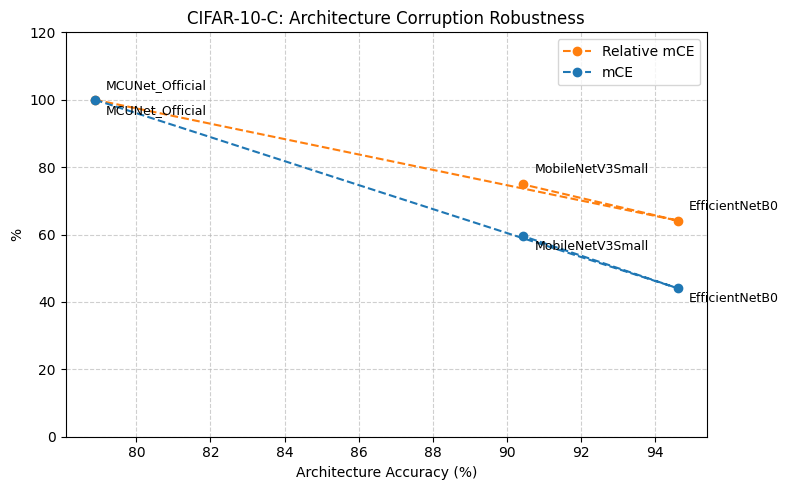


Dataset: CIFAR-100-C

CE (%) by corruption and model (15 common corruptions; mCE uses the same set)


model,EfficientNetB0,MCUNet_Official,MobileNetV3Small
corruption,,,
brightness,44.20,100.0,55.13
contrast,72.60,100.0,81.31
defocus_blur,60.24,100.0,69.23
elastic_transform,69.92,100.0,75.75
fog,69.08,100.0,85.24
frost,54.97,100.0,59.10
gaussian_noise,76.50,100.0,86.51
glass_blur,98.89,100.0,89.46
impulse_noise,68.89,100.0,100.71



Summary table


,clean_acc_pct,mCE_pct,relative_mCE_pct
MCUNet_Official,58.68,100.00,100.00
EfficientNetB0,78.32,67.35,96.33
MobileNetV3Small,73.01,76.26,96.40


Saved plot: .\figures\cifar100c_architecture_corruption_robustness.pdf


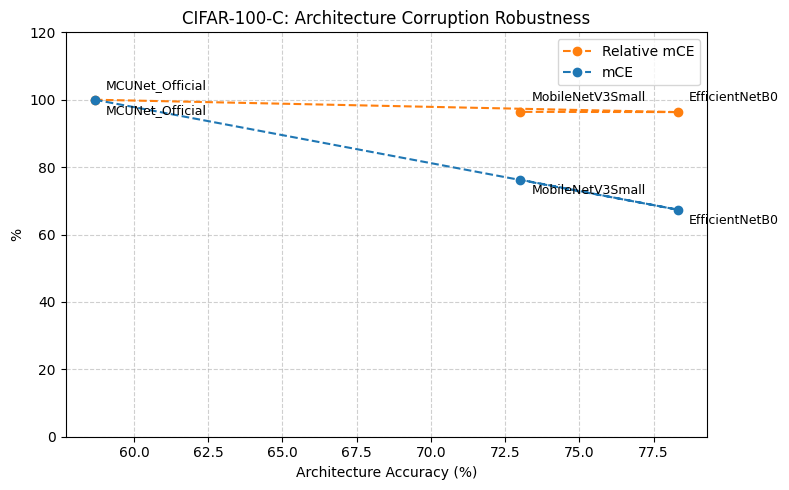


Dataset: Wake Vision-C

CE (%) by corruption and model (15 common corruptions; mCE uses the same set)


model,EfficientNetB0,MCUNet,MobileNetV3Small
corruption,,,
brightness,54.77,100.0,69.41
contrast,69.91,100.0,99.85
defocus_blur,71.78,100.0,66.29
elastic_transform,67.36,100.0,70.66
fog,58.60,100.0,90.40
frost,58.31,100.0,68.31
gaussian_noise,47.74,100.0,67.98
glass_blur,51.30,100.0,61.84
impulse_noise,47.25,100.0,70.17



Summary table


,clean_acc_pct,mCE_pct,relative_mCE_pct
MCUNet,81.27,100.00,100.00
EfficientNetB0,87.73,58.72,63.11
MobileNetV3Small,86.13,71.91,35.01


Saved plot: .\figures\wakevision_architecture_corruption_robustness.pdf


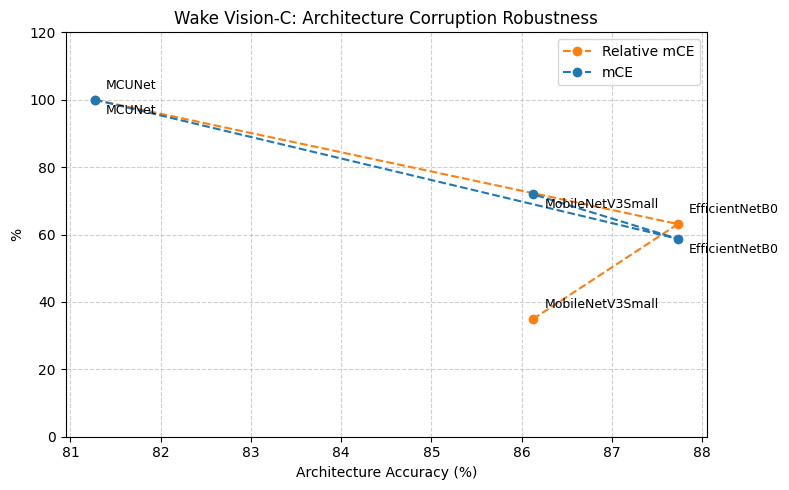

In [5]:
all_summaries = {}
all_ce_tables = {}

for key, cfg in DATASETS.items():
    print("\n" + "=" * 88)
    print(f"Dataset: {cfg['label']}")
    print("=" * 88)

    jsonl_path = cfg["jsonl"]
    if not jsonl_path.exists():
        print(f"Missing file: {jsonl_path}")
        continue

    rows = _load_latest_jsonl(jsonl_path, aliases=cfg.get("aliases", {}))
    if not rows:
        print(f"No rows loaded from: {jsonl_path}")
        continue

    baseline_name = cfg["baseline"]

    clean_acc = {}
    clean_acc_path = cfg.get("clean_acc")
    if clean_acc_path is not None and Path(clean_acc_path).exists():
        clean_acc = _load_json(Path(clean_acc_path), default={})
    elif cfg.get("clean_acc_fallback"):
        clean_acc = dict(cfg["clean_acc_fallback"])

    # Apply model aliases to clean-accuracy keys too.
    aliases = cfg.get("aliases", {})
    if aliases:
        clean_acc = {aliases.get(k, k): v for k, v in clean_acc.items()}

    ce_table = _ce_pivot(rows)
    all_ce_tables[key] = ce_table
    print("\nCE (%) by corruption and model (15 common corruptions; mCE uses the same set)")
    display(ce_table.round(2))

    mce_pct = _compute_mce(rows)
    rel_mce_pct = _compute_relative_mce(rows, clean_acc=clean_acc, baseline_name=baseline_name)

    summary = pd.DataFrame(index=sorted(set(mce_pct.index) | set(rel_mce_pct.index) | set(clean_acc.keys())))
    summary["clean_acc_pct"] = pd.Series({k: v * 100.0 for k, v in clean_acc.items()})
    summary["mCE_pct"] = mce_pct
    summary["relative_mCE_pct"] = rel_mce_pct

    # Keep baseline first in display, then sort by mCE.
    ordered_idx = [baseline_name] + [i for i in summary.sort_values("mCE_pct").index if i != baseline_name]
    summary = summary.reindex([i for i in ordered_idx if i in summary.index])

    all_summaries[key] = summary
    print("\nSummary table")
    display(summary.round(2))

    if summary["relative_mCE_pct"].isna().all():
        print("Relative mCE could not be computed (missing clean accuracy and/or baseline mapping).")

    _plot_architecture_robustness(
        dataset_label=cfg["label"],
        summary_df=summary,
        out_pdf=cfg["plot_pdf"],
    )

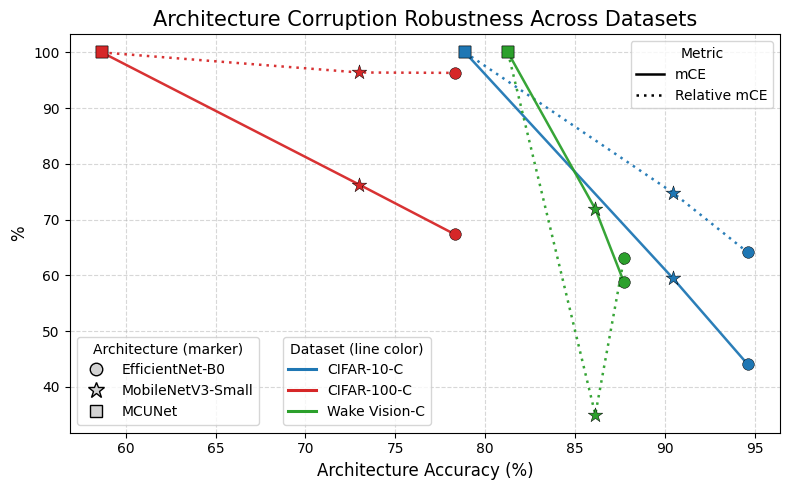

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd


dataset_colors = {
    "cifar10c": "#1f77b4",
    "cifar100c": "#d62728",
    "wakevision": "#2ca02c",
}

dataset_labels = {
    "cifar10c": "CIFAR-10-C",
    "cifar100c": "CIFAR-100-C",
    "wakevision": "Wake Vision-C",
}

arch_markers = {
    "EfficientNet-B0": "o",
    "MobileNetV3-Small": "*",
    "MCUNet": "s",
}

line_styles = {
    "mce_ls": "-",
    "rel_ls": (0, (1, 2)),
}


def _infer_arch_family(model_name: str) -> str:
    n = str(model_name).lower()
    if "efficientnet" in n:
        return "EfficientNet-B0"
    if "mobilenet" in n:
        return "MobileNetV3-Small"
    if "mcunet" in n:
        return "MCUNet"
    return model_name


fig, ax = plt.subplots(figsize=(8, 5))

for dataset_key, summary in all_summaries.items():
    if summary is None or summary.empty:
        continue

    color = dataset_colors.get(dataset_key, None)

    df = summary.copy().reset_index().rename(columns={"index": "model"})
    df["arch_family"] = df["model"].map(_infer_arch_family)

    needed = ["model", "clean_acc_pct", "mCE_pct", "relative_mCE_pct", "arch_family"]
    if not all(c in df.columns for c in needed):
        continue

    df = df.dropna(subset=["clean_acc_pct"]).copy()
    df = df.sort_values("clean_acc_pct")

    mce_df = df.dropna(subset=["mCE_pct"]).copy()
    if not mce_df.empty:
        ax.plot(
            mce_df["clean_acc_pct"],
            mce_df["mCE_pct"],
            linestyle=line_styles["mce_ls"],
            linewidth=1.8,
            color=color,
            alpha=0.95,
            zorder=1,
        )

        for _, row in mce_df.iterrows():
            marker = arch_markers.get(row["arch_family"], "o")
            ax.scatter(
                row["clean_acc_pct"],
                row["mCE_pct"],
                marker=marker,
                s=70 if marker != "*" else 120,
                color=color,
                edgecolor="black",
                linewidth=0.35,
                zorder=3,
            )

    rel_df = df.dropna(subset=["relative_mCE_pct"]).copy()
    if not rel_df.empty:
        ax.plot(
            rel_df["clean_acc_pct"],
            rel_df["relative_mCE_pct"],
            linestyle=line_styles["rel_ls"],
            linewidth=1.8,
            color=color,
            alpha=0.95,
            zorder=1,
        )

        for _, row in rel_df.iterrows():
            marker = arch_markers.get(row["arch_family"], "o")
            ax.scatter(
                row["clean_acc_pct"],
                row["relative_mCE_pct"],
                marker=marker,
                s=70 if marker != "*" else 120,
                color=color,
                edgecolor="black",
                linewidth=0.35,
                zorder=3,
            )

ax.set_title("Architecture Corruption Robustness Across Datasets", fontsize=15)
ax.set_xlabel("Architecture Accuracy (%)", fontsize=12)
ax.set_ylabel("%", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

metric_handles = [
    Line2D([0], [0], color="black", linestyle=line_styles["mce_ls"], linewidth=1.8, label="mCE"),
    Line2D([0], [0], color="black", linestyle=line_styles["rel_ls"], linewidth=1.8, label="Relative mCE"),
]
leg1 = ax.legend(handles=metric_handles, loc="upper right", title="Metric")

arch_handles = [
    Line2D(
        [0], [0],
        marker=m,
        linestyle="None",
        color="gray",
        markerfacecolor="lightgray",
        markeredgecolor="black",
        markersize=9 if m != "*" else 12,
        label=arch
    )
    for arch, m in arch_markers.items()
]
leg2 = ax.legend(
    handles=arch_handles,
    loc="lower left",
    bbox_to_anchor=(0.01, 0.02),
    title="Architecture (marker)",
    frameon=True,
    borderaxespad=0.0,
)

dataset_handles = [
    Line2D([0], [0], color=dataset_colors[k], linestyle="-", linewidth=2.2, label=v)
    for k, v in dataset_labels.items()
    if k in all_summaries
]
leg3 = ax.legend(
    handles=dataset_handles,
    loc="lower left",
    bbox_to_anchor=(0.30, 0.02),
    title="Dataset (line color)",
    frameon=True,
    borderaxespad=0.0,
)

ax.add_artist(leg1)
ax.add_artist(leg2)

plt.tight_layout()

out_dir = Path("output")
out_dir.mkdir(exist_ok=True, parents=True)
plt.savefig(out_dir / "combined_architecture_robustness.pdf", bbox_inches="tight")
plt.savefig(out_dir / "combined_architecture_robustness.png", dpi=300, bbox_inches="tight")

plt.show()

OSError: [Errno 28] No space left on device

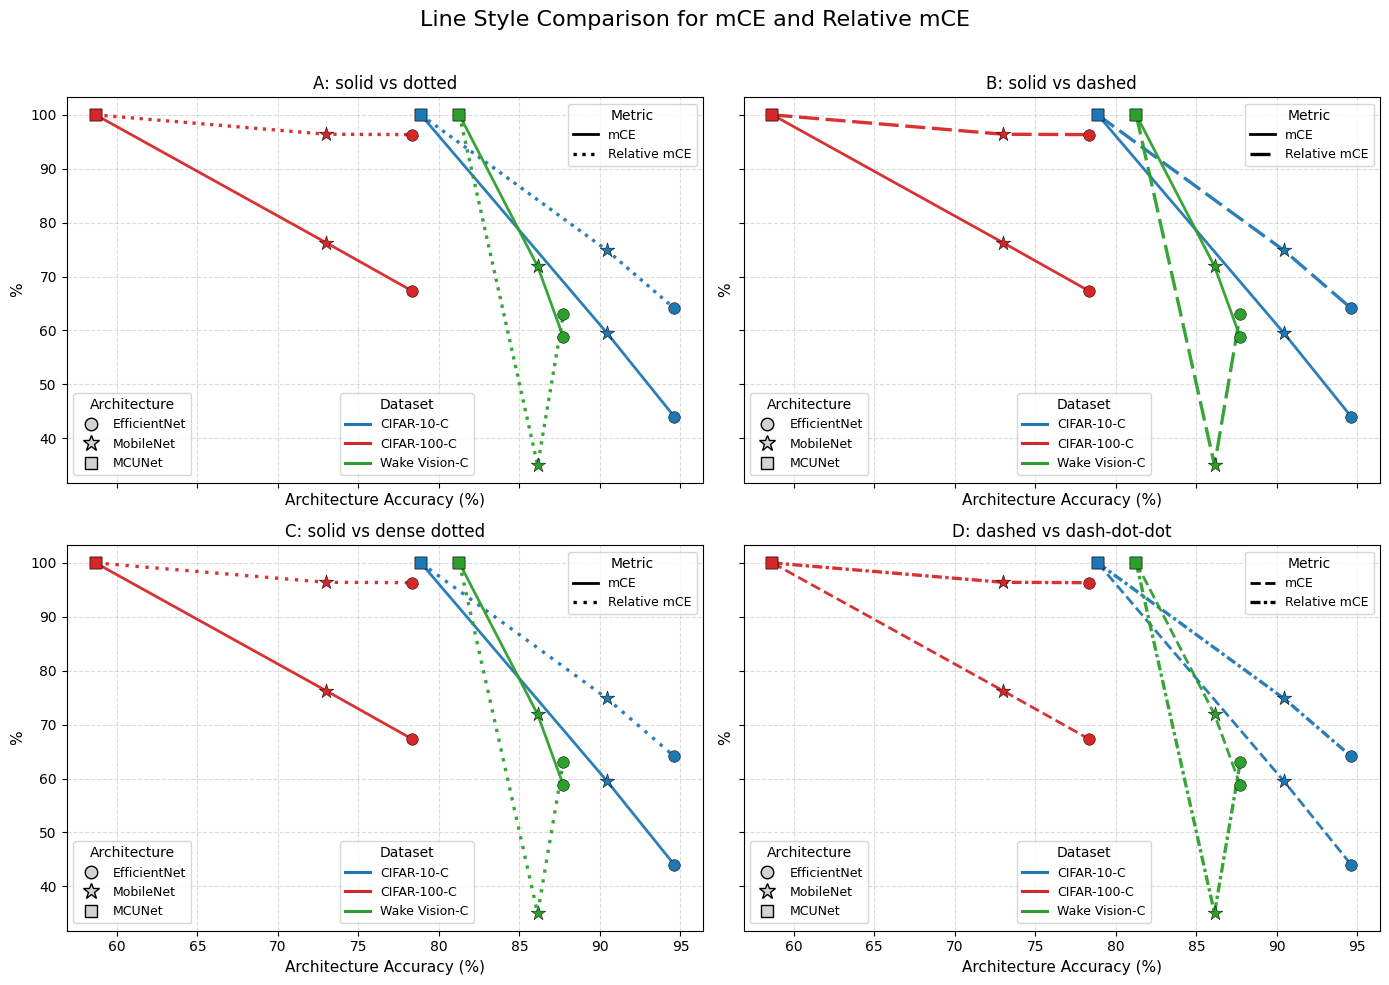

In [27]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

dataset_colors = {
    "cifar10c": "#1f77b4",
    "cifar100c": "#d62728",
    "wakevision": "#2ca02c",
}

dataset_labels = {
    "cifar10c": "CIFAR-10-C",
    "cifar100c": "CIFAR-100-C",
    "wakevision": "Wake Vision-C",
}

arch_markers = {
    "EfficientNet": "o",
    "MobileNet": "*",
    "MCUNet": "s",
}

def _infer_arch_family(model_name: str) -> str:
    n = str(model_name).lower()
    if "efficientnet" in n:
        return "EfficientNet"
    if "mobilenet" in n:
        return "MobileNet"
    if "mcunet" in n:
        return "MCUNet"
    return model_name

style_tests = [
    {
        "title": "A: solid vs dotted",
        "mce_ls": "-",
        "rel_ls": ":",
    },
    {
        "title": "B: solid vs dashed",
        "mce_ls": "-",
        "rel_ls": (0, (6, 2)),
    },
    {
        "title": "C: solid vs dense dotted",
        "mce_ls": "-",
        "rel_ls": (0, (1, 2)),
    },
    {
        "title": "D: dashed vs dash-dot-dot",
        "mce_ls": "--",
        "rel_ls": (0, (3, 1, 1, 1)),
    },
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, cfg_style in zip(axes, style_tests):
    for dataset_key, summary in all_summaries.items():
        if summary is None or summary.empty:
            continue

        color = dataset_colors.get(dataset_key, None)

        df = summary.copy().reset_index().rename(columns={"index": "model"})
        df["arch_family"] = df["model"].map(_infer_arch_family)

        needed = ["model", "clean_acc_pct", "mCE_pct", "relative_mCE_pct", "arch_family"]
        if not all(c in df.columns for c in needed):
            continue

        df = df.dropna(subset=["clean_acc_pct"]).copy()
        df = df.sort_values("clean_acc_pct")

        mce_df = df.dropna(subset=["mCE_pct"]).copy()
        if not mce_df.empty:
            ax.plot(
                mce_df["clean_acc_pct"],
                mce_df["mCE_pct"],
                linestyle=cfg_style["mce_ls"],
                linewidth=2.0,
                color=color,
                alpha=0.95,
                zorder=1,
            )

            for _, row in mce_df.iterrows():
                marker = arch_markers.get(row["arch_family"], "o")
                ax.scatter(
                    row["clean_acc_pct"],
                    row["mCE_pct"],
                    marker=marker,
                    s=70 if marker != "*" else 120,
                    color=color,
                    edgecolor="black",
                    linewidth=0.35,
                    zorder=3,
                )

        rel_df = df.dropna(subset=["relative_mCE_pct"]).copy()
        if not rel_df.empty:
            ax.plot(
                rel_df["clean_acc_pct"],
                rel_df["relative_mCE_pct"],
                linestyle=cfg_style["rel_ls"],
                linewidth=2.4,
                color=color,
                alpha=0.95,
                zorder=1,
            )

            for _, row in rel_df.iterrows():
                marker = arch_markers.get(row["arch_family"], "o")
                ax.scatter(
                    row["clean_acc_pct"],
                    row["relative_mCE_pct"],
                    marker=marker,
                    s=70 if marker != "*" else 120,
                    color=color,
                    edgecolor="black",
                    linewidth=0.35,
                    zorder=3,
                )

    ax.set_title(cfg_style["title"], fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.45)
    ax.set_axisbelow(True)
    ax.set_xlabel("Architecture Accuracy (%)", fontsize=11)
    ax.set_ylabel("%", fontsize=11)

    metric_handles = [
        Line2D([0], [0], color="black", linestyle=cfg_style["mce_ls"], linewidth=2.0, label="mCE"),
        Line2D([0], [0], color="black", linestyle=cfg_style["rel_ls"], linewidth=2.4, label="Relative mCE"),
    ]
    leg1 = ax.legend(handles=metric_handles, loc="upper right", title="Metric", fontsize=9, title_fontsize=10)

    arch_handles = [
        Line2D(
            [0], [0],
            marker=m,
            linestyle="None",
            color="gray",
            markerfacecolor="lightgray",
            markeredgecolor="black",
            markersize=9 if m != "*" else 12,
            label=arch
        )
        for arch, m in arch_markers.items()
    ]
    leg2 = ax.legend(
        handles=arch_handles,
        loc="lower left",
        bbox_to_anchor=(0.01, 0.02),
        title="Architecture",
        frameon=True,
        borderaxespad=0.0,
        fontsize=9,
        title_fontsize=10,
    )

    dataset_handles = [
        Line2D([0], [0], color=dataset_colors[k], linestyle="-", linewidth=2.2, label=v)
        for k, v in dataset_labels.items()
        if k in all_summaries
    ]
    leg3 = ax.legend(
        handles=dataset_handles,
        loc="lower left",
        bbox_to_anchor=(0.43, 0.02),
        title="Dataset",
        frameon=True,
        borderaxespad=0.0,
        fontsize=9,
        title_fontsize=10,
    )

    ax.add_artist(leg1)
    ax.add_artist(leg2)

fig.suptitle("Line Style Comparison for mCE and Relative mCE", fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.965])

out_dir = Path("output")
out_dir.mkdir(exist_ok=True, parents=True)
plt.savefig(out_dir / "linestyle_comparison_grid.pdf", bbox_inches="tight")
plt.savefig(out_dir / "linestyle_comparison_grid.png", dpi=300, bbox_inches="tight")

plt.show()

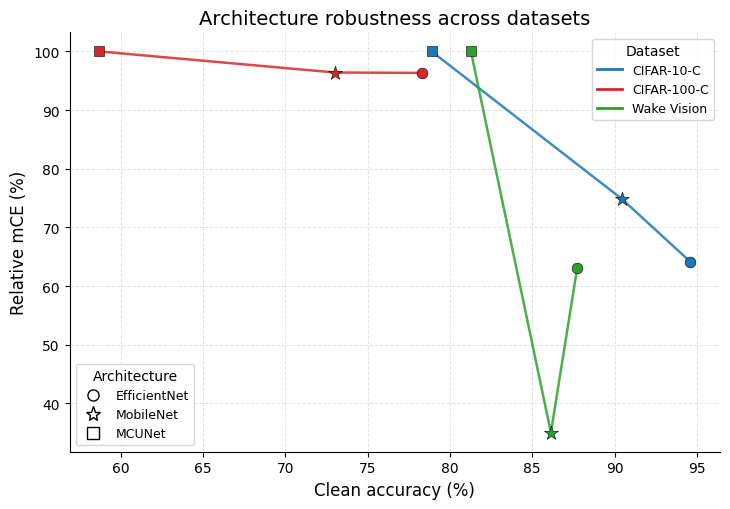

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

# Versão mais limpa:
# - um único painel
# - uma única métrica no eixo Y: relative_mCE_pct
# - cor = dataset
# - marcador = arquitetura
# - sem rótulo em cada ponto

dataset_colors = {
    "cifar10c": "#1f77b4",   # azul
    "cifar100c": "#d62728",  # vermelho
    "wakevision": "#2ca02c", # verde
}

dataset_labels = {
    "cifar10c": "CIFAR-10-C",
    "cifar100c": "CIFAR-100-C",
    "wakevision": "Wake Vision-C",
}

arch_markers = {
    "EfficientNet": "o",
    "MobileNet": "*",
    "MCUNet": "s",
}

def _infer_arch_family(model_name: str) -> str:
    n = str(model_name).lower()
    if "efficientnet" in n:
        return "EfficientNet"
    if "mobilenet" in n:
        return "MobileNet"
    if "mcunet" in n:
        return "MCUNet"
    return model_name

fig, ax = plt.subplots(figsize=(7.4, 5.2))

for dataset_key, summary in all_summaries.items():
    if summary is None or summary.empty:
        continue

    color = dataset_colors.get(dataset_key, "gray")
    label = dataset_labels.get(dataset_key, dataset_key)

    df = summary.copy().reset_index().rename(columns={"index": "model"})
    if not {"clean_acc_pct", "relative_mCE_pct", "model"}.issubset(df.columns):
        continue

    df = df.dropna(subset=["clean_acc_pct", "relative_mCE_pct"]).copy()
    if df.empty:
        continue

    df["arch_family"] = df["model"].map(_infer_arch_family)
    df = df.sort_values("clean_acc_pct")

    # linha do dataset
    ax.plot(
        df["clean_acc_pct"],
        df["relative_mCE_pct"],
        color=color,
        linewidth=1.8,
        alpha=0.85,
        zorder=1,
    )

    # pontos por arquitetura
    for _, row in df.iterrows():
        marker = arch_markers.get(row["arch_family"], "o")
        size = 60 if marker != "*" else 110
        ax.scatter(
            row["clean_acc_pct"],
            row["relative_mCE_pct"],
            marker=marker,
            s=size,
            color=color,
            edgecolor="black",
            linewidth=0.4,
            zorder=3,
        )

ax.set_title("Architecture robustness across datasets", fontsize=14)
ax.set_xlabel("Clean accuracy (%)", fontsize=12)
ax.set_ylabel("Relative mCE (%)", fontsize=12)

ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# legenda 1: datasets
dataset_handles = [
    Line2D([0], [0], color=dataset_colors[k], lw=2.0, label=v)
    for k, v in dataset_labels.items()
    if k in all_summaries
]
leg1 = ax.legend(
    handles=dataset_handles,
    title="Dataset",
    loc="upper right",
    frameon=True,
    fontsize=9,
    title_fontsize=10,
)

# legenda 2: arquiteturas
arch_handles = [
    Line2D(
        [0], [0],
        linestyle="None",
        marker=m,
        markersize=8 if m != "*" else 11,
        markerfacecolor="white",
        markeredgecolor="black",
        color="black",
        label=arch,
    )
    for arch, m in arch_markers.items()
]
leg2 = ax.legend(
    handles=arch_handles,
    title="Architecture",
    loc="lower left",
    frameon=True,
    fontsize=9,
    title_fontsize=10,
)
ax.add_artist(leg1)

plt.tight_layout()

out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "combined_relative_mce_clean.pdf", bbox_inches="tight")
plt.savefig(out_dir / "combined_relative_mce_clean.png", dpi=300, bbox_inches="tight")

plt.show()